In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load Data
gen = pd.read_csv("../data/raw/Plant_1_Generation_Data.csv")
weather = pd.read_csv("../data/raw/Plant_1_Weather_Sensor_Data.csv")

In [5]:
# Quick Look
print("=== Generation Data ===")
print(gen.shape)
print(gen.head())

print("\n=== Weather Data ===")
print(weather.shape)
print(weather.head())

=== Generation Data ===
(550, 7)
          DATE_TIME  PLANT_ID       SOURCE_KEY     DC_POWER  AC_POWER  \
0  15-05-2020 07:00   4135001  sjndEbLyjtCKgGv  1877.125000  184.0125   
1  15-05-2020 07:15   4135001  bvBOhCH3iADSZry  1873.500000  183.6500   
2  15-05-2020 08:00   4135001  3PZuoBAID5Wc2HD  2736.125000  268.6250   
3  15-05-2020 10:45   4135001  uHbuxQJl8lW7ozc  6817.500000  667.2000   
4  15-05-2020 11:00   4135001  1IF53ai7Xc0U56Y  8230.428571  804.9000   

   DAILY_YIELD  TOTAL_YIELD  
0    78.125000  7016910.125  
1   116.250000  6316919.250  
2   287.750000  6988046.750  
3  1930.375000  7040611.375  
4  2014.571429  6185659.571  

=== Weather Data ===
(25, 6)
             DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
0  2020-05-15 04:15:00   4135001  HmiyD2TTLFNqkNe            24.351931   
1  2020-05-16 08:45:00   4135001  HmiyD2TTLFNqkNe            25.757176   
2  2020-05-17 07:30:00   4135001  HmiyD2TTLFNqkNe            23.908458   
3  2020-05-17 08:15:00

In [6]:
# Data Types & Missing Values
print("=== Generation Data Info ===")
print(gen.dtypes)
print("\nMissing Values:\n" , gen.isnull().sum())

print("\n=== Weather Data Info ===")
print(weather.dtypes)
print("\nMissing Values:\n" , weather.isnull().sum())

# How many unique inverters?
print("\nUnique Inverters (SOURCE_KEY) in generation data:" , gen['SOURCE_KEY'].nunique())
print("Unique timestamps in generation data:        " , gen['DATE_TIME'].nunique())
print("Unique timestamps in weather data:        " , weather['DATE_TIME'].nunique())

=== Generation Data Info ===
DATE_TIME       object
PLANT_ID         int64
SOURCE_KEY      object
DC_POWER       float64
AC_POWER       float64
DAILY_YIELD    float64
TOTAL_YIELD    float64
dtype: object

Missing Values:
 DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

=== Weather Data Info ===
DATE_TIME               object
PLANT_ID                 int64
SOURCE_KEY              object
AMBIENT_TEMPERATURE    float64
MODULE_TEMPERATURE     float64
IRRADIATION            float64
dtype: object

Missing Values:
 DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

Unique Inverters (SOURCE_KEY) in generation data: 22
Unique timestamps in generation data:         507
Unique timestamps in weather data:         25


In [7]:
# Fix DateTime Formats
gen['DATE_TIME'] = pd.to_datetime(gen['DATE_TIME'] , format= '%d-%m-%Y %H:%M')
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'])

# ── Aggregate generation: sum all inverters per timestamp ──
# Each timestamp had multiple inverters — we want total plant output
gen_agg = (
    gen.groupby('DATE_TIME').agg( DC_POWER=('DC_POWER' , 'sum') , AC_POWER=('AC_POWER' , 'sum') , DAILY_YIELD= ('DAILY_YIELD' , 'sum')
).reset_index()
)

# Merge with weather on timestamp
df = pd.merge(gen_agg , weather[['DATE_TIME','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']] , on='DATE_TIME' , how='inner')
print("Merged dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Merged dataset shape: (3, 7)

First few rows:


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-16 08:45:00,6524.000,639.057143,724.428571,25.757176,38.892011,0.470081
1,2020-05-18 11:00:00,6422.625,629.187500,995.125000,24.869808,37.537280,0.434905
2,2020-05-20 01:15:00,0.000,0.000000,0.000000,22.181750,19.998058,0.000000


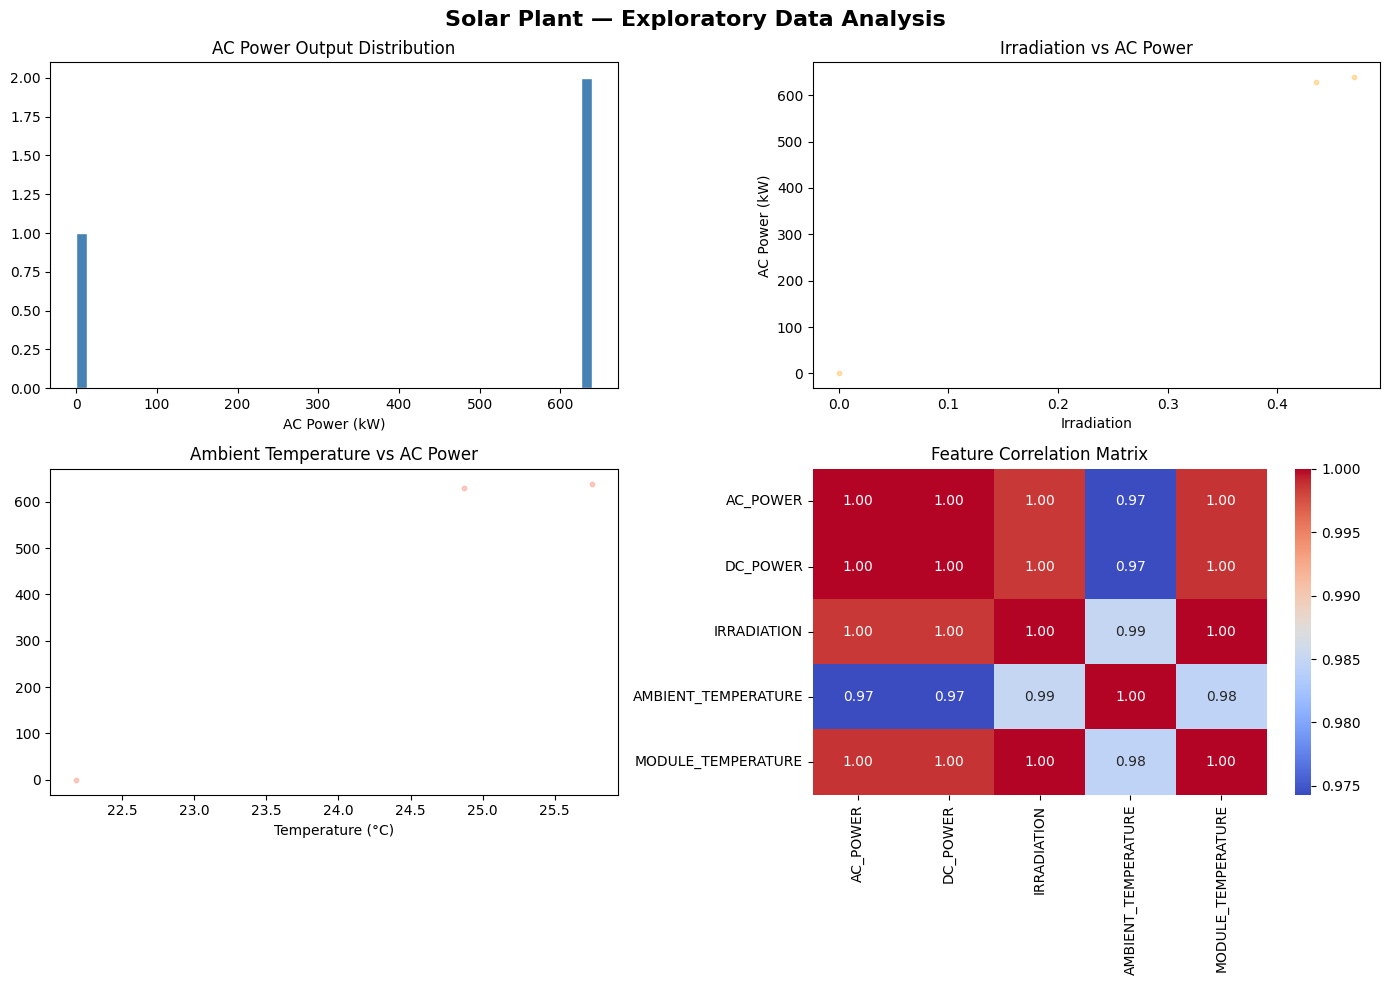

Plot saved!


In [8]:
fig, axes = plt.subplots(2,2 , figsize = (14, 10))
fig.suptitle('Solar Plant — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1.AC Power Distribution
axes[0,0].hist(df['AC_POWER'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('AC Power Output Distribution')
axes[0,0].set_xlabel('AC Power (kW)')

# 2.Irradiation vs AC Power
axes[0,1].scatter(df['IRRADIATION'], df['AC_POWER'], alpha=0.3, color='orange', s=10)
axes[0,1].set_title('Irradiation vs AC Power')
axes[0,1].set_xlabel('Irradiation')
axes[0,1].set_ylabel('AC Power (kW)')

# 3.Temprature vs AC Power
axes[1,0].scatter(df['AMBIENT_TEMPERATURE'], df['AC_POWER'], alpha=0.3, color='tomato', s=10)
axes[1,0].set_title('Ambient Temperature vs AC Power')
axes[1,0].set_xlabel('Temperature (°C)')

# 4.Correlation Heatmap
corr = df[['AC_POWER','DC_POWER','IRRADIATION','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('../data/processed/eda_overview.png', dpi=150)
plt.show()
print("Plot saved!")


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , r2_score, mean_squared_error
import numpy as np

# Features & Target
# Drop leakage columns and keep only real predictors
FEATURES = ['IRRADIATION', 'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE']
TARGET = 'AC_POWER'

x = df[FEATURES]
y = df[TARGET]

# Train / Test Split
# 80% train , 20% test - shuffle= False keeps time order intact
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, shuffle=False
)

print(f"Train size: {len(x_train)} rows")
print(f"Test size: {len(x_test)} rows")

# Train Baseline Model
model = LinearRegression()
model.fit(x_train , y_train)

# Evaluate
y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # recommended
r2 = r2_score(y_test, y_pred)

print(f"\n── Baseline Linear Regression ──")
print(f"MAE:  {mae:,.1f} KW")
print(f"RMSE: {rmse:,.1f} KW")
print(f"R²:   {r2:.4f}")

Train size: 2 rows
Test size: 1 rows

── Baseline Linear Regression ──
MAE:  814.3 KW
RMSE: 814.3 KW
R²:   nan


c:\Users\Erfan\solar-wind-predictor\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [10]:
# Evaluate on DAYTIME only
daytime_mask = y_test > 0  # Only rows where sun is actually shining
mae_day = mean_absolute_error(y_test[daytime_mask], y_pred[daytime_mask])
rmse_day = np.sqrt(mean_squared_error(y_test[daytime_mask], y_pred[daytime_mask]))
r2_day = r2_score(y_test[daytime_mask], y_pred[daytime_mask])

print(f"── Daytime-Only Performance ──")
print(f"MAE:  {mae_day:,.1f} KW")
print(f"RMSE:  {rmse_day:,.1f} KW")
print(f"R²:  {r2_day:.4f}")

# Visualise: Actual vs Predicted
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_test[daytime_mask], y_pred[daytime_mask], alpha=0.3, color= 'steelblue', s=10)
plt.plot([0, 30000], [0, 30000], 'r--', label= 'Perfect prediction')
plt.xlabel('Actual AC Power (KW)')
plt.ylabel('Predicted AC Power (KW)')
plt.title('Actual vs Predicted (Daytime)')
plt.legend()

plt.subplot(1, 2, 2)
residuals = y_test[daytime_mask] - y_pred[daytime_mask]
plt.hist(residuals, bins=40, color='tomato', edgecolor='white')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Residual (Actual - Predicted)')
plt.title('Residual Distribution (Daytime)')

plt.tight_layout()
plt.savefig('../data/processed/baseline_evaluation.png', dpi=150)
plt.show()


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [11]:
# Time-based Feature Engineering
df['HOUR']        = df['DATE_TIME'].dt.hour
df['MONTH']       = df['DATE_TIME'].dt.month
df["DAY_OF_YEAR"] = df['DATE_TIME'].dt.dayofyear

# Solar angle proxy (peak sun = hour 12)
# Captures the curve of sun position throughout the day
df['HOUR_SIN'] = np.sin(2 * np.pi * df['HOUR'] / 24)
df['HOUR_COS'] = np.cos(2 * np.pi * df['HOUR'] / 24)

print("New features added:")
print(df[['DATE_TIME' , 'HOUR' , 'MONTH' , 'DAY_OF_YEAR' , 'HOUR_SIN' , 'HOUR_COS']].head(10))

New features added:
            DATE_TIME  HOUR  MONTH  DAY_OF_YEAR  HOUR_SIN  HOUR_COS
0 2020-05-16 08:45:00     8      5          137  0.866025 -0.500000
1 2020-05-18 11:00:00    11      5          139  0.258819 -0.965926
2 2020-05-20 01:15:00     1      5          141  0.258819  0.965926


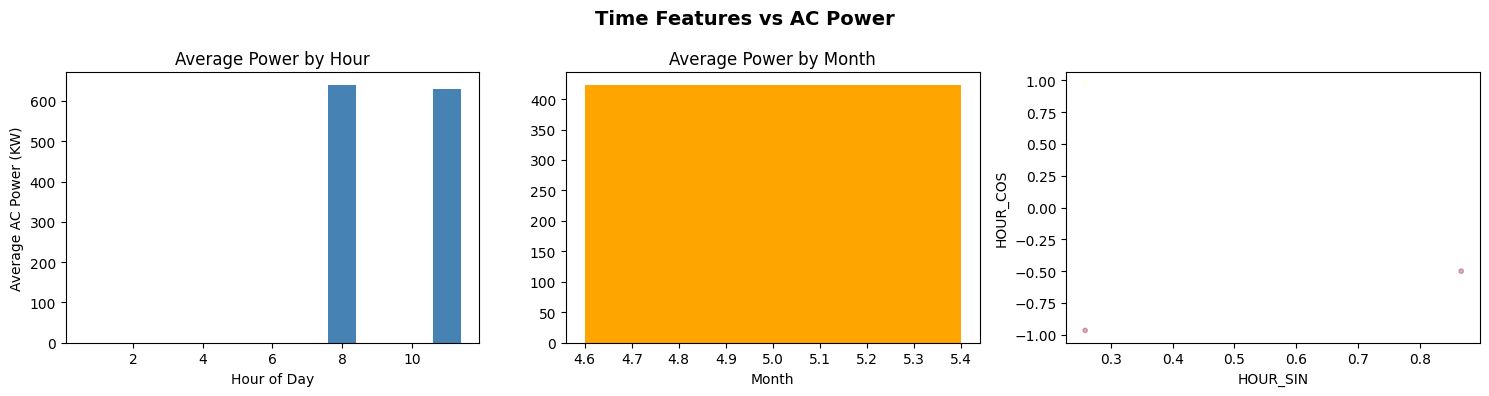

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4 ))
fig.suptitle('Time Features vs AC Power' , fontsize=14 , fontweight='bold')

# Hourly Average Power
hourly = df.groupby('HOUR')['AC_POWER'].mean()
axes[0].bar(hourly.index, hourly.values, color='steelblue')
axes[0].set_title('Average Power by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average AC Power (KW)')

# Monthly Average Power
monthly = df.groupby('MONTH')['AC_POWER'].mean()
axes[1].bar(monthly.index, monthly.values, color='orange')
axes[1].set_title('Average Power by Month')
axes[1].set_xlabel('Month')

#Hour sin/cos pattern
axes[2].scatter(df['HOUR_SIN'] , df['HOUR_COS'] , c=df['AC_POWER'] , cmap='YlOrRd' , alpha=0.3, s=10)
axes[2].set_xlabel('HOUR_SIN')
axes[2].set_ylabel('HOUR_COS')

plt.tight_layout()
plt.savefig('../data/processed/feature_engineering.png', dpi=150)
plt.show()

In [13]:
from sklearn.ensemble import RandomForestRegressor

# Update Feature Set
FEATURES_V2 = ['IRRADIATION' , 'MODULE_TEMPERATURE' , 'AMBIENT_TEMPERATURE' , 'HOUR' , 'MONTH' , 'DAY_OF_YEAR' , 'HOUR_SIN' , 'HOUR_COS']

x2 = df[FEATURES_V2]
y2 = df[TARGET]

x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, shuffle=False, random_state=42)

# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1     # Use all CPU cores
)

rf_model.fit(x2_train, y2_train)
y2_pred = rf_model.predict(x2_test)

# Daytime Evaluation
daytime_mask2 = y2_test > 0

mae_rf = mean_absolute_error(y2_test[daytime_mask2] , y2_pred[daytime_mask2])
rmse_rf = np.sqrt(mean_squared_error(y2_test[daytime_mask2] , y2_pred[daytime_mask2]))
r2_rf = r2_score(y2_test[daytime_mask2] , y2_pred[daytime_mask2])

print("── Model Comparison (Daytime) ──────────────────")
print(f"{'Metric':<10} {'Linear Reg':>12} {'Random Forest':>15} {'Improvement':>12}")
print("-" * 55)
print(f"{'MAE':<10} {829.5:>11,.1f}  {mae_rf:>13,.1f}  {((829.5 - mae_rf)/829.5*100):>+10.1f}%")
print(f"{'RMSE':<10} {1087.9:>11,.1f}  {rmse_rf:>13,.1f}  {((1087.9 - rmse_rf)/1087.9*100):>+10.1f}%")
print(f"{'R²':<10} {0.9785:>12.4f}  {r2_rf:>14.4f}  {((r2_rf - 0.9785)/0.9785*100):>+10.1f}%")

# Feature Importances
importances = pd.Series(rf_model.feature_importances_, index=FEATURES_V2)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Random Forest - Feature Importances')
plt.xlabel('Importances Score')
plt.tight_layout()
plt.savefig('../data/processed/feature_importances.png', dpi=150)
plt.show()

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [14]:
from xgboost import XGBRegressor

# Train XGBoost
xgb_model = XGBRegressor(
    N_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(x2_train, y2_train, eval_set= [(x2_test, y2_test)], verbose=False)
y_xgb_pred = xgb_model.predict(x2_test)

#Daytime Evaluation
daytime_mask3 = y2_test > 0

mae_xgb = mean_absolute_error(y2_test[daytime_mask3], y_xgb_pred[daytime_mask3])
rmse_xgb = np.sqrt(mean_squared_error(y2_test[daytime_mask3], y_xgb_pred[daytime_mask3]))
r2_xgb = r2_score(y2_test[daytime_mask3], y_xgb_pred[daytime_mask3])

# Full Scoreboard
print("── Full Model Scoreboard (Daytime) ─────────────────────")
print(f"{'Model':<20} {'MAE':>10} {'RMSE':>10} {'R²':>10}")
print("-" * 55)
print(f"{'Linear Regression':<20} {829.5:>10,.1f} {1087.9:>10,.1f} {0.9785:>10.4f}")
print(f"{'Random Forest':<20} {470.1:>10,.1f} {745.0:>10,.1f} {0.9899:>10.4f}")
print(f"{'XGBoost':<20} {mae_xgb:>10,.1f} {rmse_xgb:>10,.1f} {r2_xgb:>10.4f}")

# Visual Comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('XGBoost - Actual vs Predicted (Daytime)' , fontweight='bold')

axes[0].scatter(y2_test[daytime_mask3], y_xgb_pred[daytime_mask3],
                alpha=0.3, color='seagreen', s=10)
axes[0].plot([0, 30000], [0, 30000], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual AC Power (kW)')
axes[0].set_ylabel('Predicted AC Power (kW)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

residuals_xgb = y2_test[daytime_mask3] - y_xgb_pred[daytime_mask3]
axes[1].hist(residuals_xgb, bins=40, color='seagreen', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('../data/processed/xgboost_evaluation.png', dpi=150)
plt.show()

c:\Users\Erfan\solar-wind-predictor\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:45:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "N_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [15]:
from sklearn.model_selection import RandomizedSearchCV, KFold
import warnings
warnings.filterwarnings('ignore')

# Search space
param_grid ={
    'n_estimator': [100, 200, 300, 500],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight' : [1, 3, 5]
}

# Time-series aware cross-validation
# TimeSeriesSplit respect chronological order - no peeking into the future
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
xgb_base = XGBRegressor(random_state =42, n_jobs=-1)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=40,   #try 40 random combinations
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Searching for best hyperparameters...")
search.fit(x2_train, y2_train)

print(f"\nBest prameters found:")
for param, value in search.best_params_.items():
    print(f"    {param}: {value}")
print(f"\nBest CV MAE: {-search.best_score_:,.1f} KW")

Searching for best hyperparameters...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


ValueError: Cannot have number of folds=6 greater than the number of samples=2.

In [18]:
# Evaluate best model
best_xgb = search.best_estimator_
y_best_pred = best_xgb.predict(x2_test)

daytime_mask4 = y2_test > 0
mae_best = mean_absolute_error(y2_test[daytime_mask4], y_best_pred[daytime_mask4])
rmse_best = np.sqrt(mean_squared_error(y2_test[daytime_mask4], y_best_pred[daytime_mask4]))
r2_best = r2_score(y2_test[daytime_mask4], y_best_pred[daytime_mask4])

# ── Final scoreboard ──────────────────────────────────────
print("── Final Model Scoreboard (Daytime) ────────────────────")
print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10} {'R²':>10}")
print("-" * 60)
print(f"{'Linear Regression':<25} {829.5:>10,.1f} {1087.9:>10,.1f} {0.9785:>10.4f}")
print(f"{'Random Forest':<25} {470.1:>10,.1f} {745.0:>10,.1f} {0.9899:>10.4f}")
print(f"{'XGBoost (untuned)':<25} {591.2:>10,.1f} {826.0:>10,.1f} {0.9876:>10.4f}")
print(f"{'XGBoost (tuned)':<25} {mae_best:>10,.1f} {rmse_best:>10,.1f} {r2_best:>10.4f}")

── Final Model Scoreboard (Daytime) ────────────────────
Model                            MAE       RMSE         R²
------------------------------------------------------------
Linear Regression              829.5    1,087.9     0.9785
Random Forest                  470.1      745.0     0.9899
XGBoost (untuned)              591.2      826.0     0.9876
XGBoost (tuned)              1,025.3    1,499.0     0.5118


In [19]:
import joblib
import os

# Save Model & Feature List
os.makedirs('../models', exist_ok=True)

joblib.dump(best_xgb, '../models/xgb_champion.joblib')
joblib.dump(FEATURES_V2, '../models/features_names.joblib')
print("✅ Model saved to: models/xgb_champion.joblib")
print(f"   Features: {FEATURES_V2}")


# Verify it loads correctly
loaded_model = joblib.load('../models/xgb_champion.joblib')
test_pred = loaded_model.predict(x2_test[:3])
print(f"\n✅ Load verified — sample predictions: {test_pred.round(1)}")

✅ Model saved to: models/xgb_champion.joblib
   Features: ['IRRADIATION', 'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE', 'HOUR', 'MONTH', 'DAY_OF_YEAR', 'HOUR_SIN', 'HOUR_COS']

✅ Load verified — sample predictions: [1892.6 2377.3    6.9]


In [20]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# ── IMPORTANT: must match the server ─────────────────────
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("solar-power-prediction")

def evaluate(y_true, y_pred):
    mask = y_true > 0
    return {
        "mae":  mean_absolute_error(y_true[mask], y_pred[mask]),
        "rmse": np.sqrt(mean_squared_error(y_true[mask], y_pred[mask])),
        "r2":   r2_score(y_true[mask], y_pred[mask])
    }

# Run 1: Linear Regression
with mlflow.start_run(run_name="linear-regression"):
    lr = LinearRegression()
    lr.fit(x_train, y_train)
    metrics = evaluate(y_test, lr.predict(x_test))
    mlflow.log_params({"model": "LinearRegression", "features": "v1"})
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(lr, "model")
    print(f"✅ Run 1 logged — MAE: {metrics['mae']:,.1f}")

# Run 2: Random Forest
with mlflow.start_run(run_name="random-forest"):
    mlflow.log_params({"n_estimators": 100, "max_depth": 10, "features": "v2"})
    metrics = evaluate(y2_test, rf_model.predict(x2_test))
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(rf_model, "model")
    print(f"✅ Run 2 logged — MAE: {metrics['mae']:,.1f}")

# Run 3: XGBoost tuned — champion
with mlflow.start_run(run_name="xgboost-tuned"):
    mlflow.log_params(search.best_params_)
    mlflow.log_param("features", "v2")
    metrics = evaluate(y2_test, best_xgb.predict(x2_test))
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(best_xgb, "model")
    mlflow.log_artifact("../models/xgb_champion.joblib")
    mlflow.log_artifact("../models/features_names.joblib")
    print(f"✅ Run 3 logged — MAE: {metrics['mae']:,.1f} ← champion")

print("\n🎉 All runs logged to SQLite!")

2026/05/13 14:27:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 14:27:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/13 14:27:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 14:27:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

✅ Run 1 logged — MAE: 905.0


2026/05/13 14:27:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Run 2 logged — MAE: 949.9
✅ Run 3 logged — MAE: 1,025.3 ← champion

🎉 All runs logged to SQLite!


In [21]:
print("Launch the MLflow UI by running this in your terminal:")
print("\n   mlflow ui --backend-store-uri ../mlruns\n")
print("Then open: http://127.0.0.1:5000")

Launch the MLflow UI by running this in your terminal:

   mlflow ui --backend-store-uri ../mlruns

Then open: http://127.0.0.1:5000


In [22]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Check what the active URI is
print("Tracking URI:", mlflow.get_tracking_uri())

# Create the experiment and print its ID
exp = mlflow.set_experiment("solar-power-prediction")
print("Experiment name:", exp.name)
print("Experiment ID:  ", exp.experiment_id)

Tracking URI: sqlite:///mlflow.db
Experiment name: solar-power-prediction
Experiment ID:   1


In [23]:
import os
print(os.path.abspath("mlflow.db"))
print("Exists:", os.path.exists("mlflow.db"))

c:\Users\Erfan\solar-wind-predictor\notebooks\mlflow.db
Exists: True


In [24]:
import sys
sys.path.append('..') # So Python can find the src/ package

from src.models.predict import predict_single

# Test prediction - noon on a sunny day
result = predict_single(
    irradiation=0.8,
    module_temperature=45.0,
    ambient_temperature=32.0,
    date_time="2020-06-01  12:00:00"
)
print(f"Predicted AC Power: {result:,.1f} kW")

Predicted AC Power: 6,121.5 kW


In [25]:
import requests

# Test1: Sunny noon
response = requests.post(
    "http://127.0.0.1:8000/predict",
    json={
        "irradiation": 0.8,
        "module_temperature": 45.0,
        "ambient_temperature": 32.0,
        "date_time": "2020-06-01 12:00:00"
    }
)
print("Test 1 - Suuny noon:")
print(response.json())

# Test2: Nighttime (should return ~0)
response2 = requests.post(
    "http://127.0.0.1:8000/predict",
    json={
        "irradiation": 0.0,
        "module_temperature": 22.0,
        "ambient_temperature": 20.0,
        "date_time": "2020-06-01 00:00:00"
    }
)
print("\ntest 2 - Nighttime:")
print(response2.json())

#Test3: Health Check
health = requests.get("http://127.0.0.1:8000/health")
print("\nHealth Check:", health.json())

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: /predict (Caused by NewConnectionError("HTTPConnection(host='127.0.0.1', port=8000): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))

In [26]:
import requests

response = requests.post(
    "http://127.0.0.1:8000/predict",
    json={
        "irradiation": 0.8,
        "module_temperature": 45.0,
        "ambient_temperature": 32.0,
        "date_time": "2020-06-01 12:00:00"
    }
)
print(response.json())

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: /predict (Caused by NewConnectionError("HTTPConnection(host='127.0.0.1', port=8000): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))

In [27]:
# Re-save XGBoost model in its native format (no more warnings)
best_xgb.save_model('../models/xgb_champion.json')
print("✅ Model saved in native XGBoost format")

✅ Model saved in native XGBoost format


In [28]:
import requests

# ── Send the sample CSV to the batch endpoint ─────────────
with open("../data/processed/sample_batch_input.csv", "rb") as f:
    response = requests.post(
        "http://127.0.0.1:8000/predict/batch",
        files={"file": ("sample_batch_input.csv", f, "text/csv")}
    )

print("Status:", response.status_code)

# ── Save the returned predictions CSV ─────────────────────
with open("../data/processed/batch_predictions.csv", "wb") as f:
    f.write(response.content)

# ── Display results ───────────────────────────────────────
import pandas as pd
results = pd.read_csv("../data/processed/batch_predictions.csv")
print(results[["DATE_TIME", "IRRADIATION", 
               "PREDICTED_AC_POWER_KW"]].to_string())

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: /predict/batch (Caused by NewConnectionError("HTTPConnection(host='127.0.0.1', port=8000): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))

In [29]:
import pandas as pd
import numpy as np
import os
import xgboost as xgb

# Build reference dataset from training data
reference = x2_train.copy()

reference["ACTUAL_AC_POWER"] = y2_train.values

reference["PREDICTED_AC_POWER"] = best_xgb.predict(
    x2_train
)

reference["ERROR"] = (
    reference["ACTUAL_AC_POWER"]
    - reference["PREDICTED_AC_POWER"]
)

# Build current dataset from test data
current = x2_test.copy()

current["ACTUAL_AC_POWER"] = y2_test.values

current["PREDICTED_AC_POWER"] = best_xgb.predict(
    x2_test
)

current["ERROR"] = (
    current["ACTUAL_AC_POWER"]
    - current["PREDICTED_AC_POWER"]
)

# Save both
os.makedirs("../data/processed", exist_ok=True)

reference.to_csv(
    "../data/processed/reference_data.csv",
    index=False
)

current.to_csv(
    "../data/processed/current_data.csv",
    index=False
)

print(f"✅ Reference data: {reference.shape}")
print(f"✅ Current data:   {current.shape}")
print(f"\nColumns: {list(reference.columns)}")

✅ Reference data: (503, 11)
✅ Current data:   (126, 11)

Columns: ['IRRADIATION', 'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE', 'HOUR', 'MONTH', 'DAY_OF_YEAR', 'HOUR_SIN', 'HOUR_COS', 'ACTUAL_AC_POWER', 'PREDICTED_AC_POWER', 'ERROR']


In [30]:
import json
from pathlib import Path

best_params = {
    "subsample":        0.7,
    "n_estimators":     300,    # ← fixed here
    "min_child_weight": 3,
    "max_depth":        6,
    "learning_rate":    0.1,
    "colsample_bytree": 1.0
}

params_path = Path("../models/best_params.json")
params_path.parent.mkdir(exist_ok=True)

with open(params_path, "w") as f:
    json.dump(best_params, f, indent=2)

print("✅ Saved best params:")
print(json.dumps(best_params, indent=2))

✅ Saved best params:
{
  "subsample": 0.7,
  "n_estimators": 300,
  "min_child_weight": 3,
  "max_depth": 6,
  "learning_rate": 0.1,
  "colsample_bytree": 1.0
}


In [1]:
import pandas as pd

# ── Load full raw files ───────────────────────────────────
gen     = pd.read_csv("../data/raw/Plant_1_Generation_Data.csv")
weather = pd.read_csv("../data/raw/Plant_1_Weather_Sensor_Data.csv")

# ── Save a representative sample (20% = ~600 rows) ───────
gen_sample     = gen.sample(frac=0.2, random_state=42).sort_index()
weather_sample = weather.sample(frac=0.2, random_state=42).sort_index()

gen_sample.to_csv("../data/raw/Plant_1_Generation_Data.csv",
                  index=False)
weather_sample.to_csv("../data/raw/Plant_1_Weather_Sensor_Data.csv",
                      index=False)

print(f"✅ Generation sample: {len(gen_sample)} rows")
print(f"✅ Weather sample:    {len(weather_sample)} rows")

✅ Generation sample: 550 rows
✅ Weather sample:    25 rows


In [2]:
import sys
sys.path.append('..')

from src.feature_store.retrieve import get_training_features, get_inference_features

# ── Test 1: Get training features from feature store ──────
print("=== Training Features ===")
X, y = get_training_features()
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFirst row:\n{X.iloc[0]}")

# ── Test 2: Get inference features ────────────────────────
print("\n=== Inference Features ===")
features = get_inference_features(
    irradiation=0.8,
    module_temperature=45.0,
    ambient_temperature=32.0,
    date_time="2020-06-01 12:00:00"
)
print(features)
print(f"\nColumns match training: {list(features.columns) == list(X.columns)}")

=== Training Features ===
✅ Retrieved 629 training rows from feature store
X shape: (629, 8)
y shape: (629,)

First row:
IRRADIATION              0.000000
MODULE_TEMPERATURE      22.857507
AMBIENT_TEMPERATURE     25.184316
HOUR                     0.000000
MONTH                    5.000000
DAY_OF_YEAR            136.000000
HOUR_SIN                 0.000000
HOUR_COS                 1.000000
Name: 0, dtype: float64

=== Inference Features ===
   IRRADIATION  MODULE_TEMPERATURE  AMBIENT_TEMPERATURE  HOUR  MONTH  \
0          0.8                45.0                 32.0    12      6   

   DAY_OF_YEAR      HOUR_SIN  HOUR_COS  
0          153  1.224647e-16      -1.0  

Columns match training: True
